# IT Security Agent - Week 3
### Wiring the full agent pipeline: input parsers -> local cache -> model -> XAI -> triage -> report

**Course:** AI & Ethics - IT Security Agent project

This notebook is the integration deliverable: every module built since Week
2 (`it_security_agent/`, a proper package now, not notebook-inline helpers)
wired into one end-to-end run - unified component list in, a triaged,
explainable, human-review-flagged report out.

## Weekly Status

### What did we do this week?
Since Week 2's baseline classifier (a notebook-only prototype), the
detection logic moved into a real package, `it_security_agent/`, with 18
modules and a pytest suite (69 tests, 94% coverage - see the last cell of
this notebook for the exact run). This week's job was to prove it actually
works end to end, not just module by module:

- **Three input paths** feeding one component schema: `repo_scan.py`
  (`uv.lock`/`package-lock.json`), `sbom.py` (CycloneDX/SPDX), and
  `image_scan.py` (Syft-based container scanning).
- **A local NVD cache** (`nvd_cache.py`, SQLite) plus a **CPE Dictionary
  client** and a **PyPI/npm registry client** - replacing Week 2's
  live-per-package NVD calls with one sync up front, then only local
  lookups during a scan.
- **`normalize.py`**: turns Week 2's ad hoc keyword-alignment scoring into
  a real purl-to-CPE vendor resolver, adding a registry-overlap signal
  (does the CPE product's reference URL share a domain with the package's
  registry homepage/repo?) as the training-label source.
- **`labeling.py`**: builds a training set from that registry-overlap
  signal directly (not hand-labeled like Week 2's 28 pairs) - the label
  and the model's own features are kept strictly separate so
  `registry_overlap` never leaks into `FEATURES` (regression-tested).
- **`model.py`**: trains logistic regression *and* random forest, compares
  them on Week 2's FN/FP-weighted risk score, and persists only the
  winner.
- **`explain.py`**: SHAP explanations (`LinearExplainer`/`TreeExplainer`
  depending on which model won) for anything the triage policy doesn't
  auto-confirm.
- **`agent.py`**: the triage policy itself - every match becomes
  `confirmed`, `escalated` (KEV-listed, i.e. actively exploited),
  `review_queue` (low-confidence, SHAP-explained for a human), or
  `rejected`, cross-checked against OSV.dev where possible.
- **`report.py`**: JSON + HTML output of all four buckets plus an
  OSV-agreement rate as a sanity metric on the model's own confirmed
  findings.

This notebook is the first time all of that runs together against a real
component list.

### What were our challenges?
- **NVD's `lastModified` filter isn't just "recent CVEs".** We planned to
  scope the local sync to a `lastModStartDate`/`lastModEndDate` window to
  avoid Week 1's ~3-minute full-catalog backfill. Checking `totalResults`
  for a few window sizes first: 3 days -> 781, 7 days -> 4,049, 14 days ->
  7,763, **30 days -> 347,572** (essentially the whole catalog - NVD
  appears to have run a mass reanalysis pass roughly a month before this
  run, touching almost every CVE's `lastModified` timestamp regardless of
  how old the CVE actually is). A 30/90-day window would have silently
  turned our "scoped" sync back into a full backfill, which is exactly
  the kind of long-running step we were trying to avoid. We used a
  **14-day window** instead.
- **The package isn't pip-installed.** `it_security_agent/` has no
  `[build-system]` in `pyproject.toml` yet - pytest works because of its
  own rootdir-insertion behavior, but a plain Jupyter kernel process
  doesn't get that for free. This notebook adds the repo root to
  `sys.path` explicitly (first code cell) rather than silently failing an
  import; packaging it properly is next-steps work.
- **Syft isn't installed in this environment** (and container scanning
  needs Docker too), so `image_scan.scan_image(...)` is included but
  commented out below - `image_scan.py` itself is unit-tested with a
  mocked Syft subprocess (`tests/test_image_scan.py`), just not run live
  here.
- **CPE Dictionary calls have no built-in pacing, and one hung for 20+
  minutes.** Unlike the CVE endpoint (`nvd_client.py`), `cpe_dictionary.
  search()` makes one unpaced, un-retried request per uncached keyword
  with a 90s timeout. A first full-scale attempt at pre-warming this cache
  for all ~137 `uv.lock` names stalled for over 20 minutes - we checked
  the SQLite cache mid-run and found only 2 of 137 names had been stored,
  meaning something was genuinely stuck, not just slow. We rebuilt that
  cell with a tighter 20s per-request timeout, exception handling that
  skips a failed name instead of blocking on it, and a hard 240s
  wall-clock budget on the whole loop - and, since the same fan-out
  pattern (one request per component, per service) repeats in the
  training and triage sections, scoped the live network-calling sections
  to a bounded subset of components (Section 1d) rather than the full
  unified list, so a presentation run finishes reliably.

### What are our next steps?
- Give `it_security_agent` a real `[build-system]`/editable install so
  notebooks don't need the `sys.path` workaround.
- Grow the labeled training set past the registry-overlap heuristic (it's
  a real signal, but it's still a proxy - Week 2's risk-analysis framing
  about false negatives being more expensive than false positives still
  applies to whatever replaces it).
- Get Syft available in this environment (or an equivalent) so
  `image_scan.py`'s live path gets exercised outside of its mocked tests.
- Feed this week's `report.py` output (JSON/HTML) into whatever
  presentation layer is next - right now it's written to disk and read
  back into this notebook, not surfaced anywhere else.

---
## 1. Input: a unified component list from all three input paths

Everything downstream still consumes the same **(name, version, ecosystem,
purl)** shape from Week 1/2 - now built by three separate, independently
tested parsers instead of one inline lockfile reader.

The package isn't pip-installed (see Weekly Status), so we add the repo
root to `sys.path` before importing it.

In [1]:
import json
import sys
import time
import datetime
from pathlib import Path

sys.path.insert(0, "..")  # it_security_agent isn't pip-installed; see Weekly Status

import pandas as pd
import requests
import shap
from dotenv import load_dotenv

from it_security_agent import (
    repo_scan, sbom, nvd_cache, cpe_dictionary, kev, labeling, model, explain, agent, report,
)

load_dotenv(Path("..") / ".env")
import os
NVD_API_KEY = os.environ.get("NVD_API_KEY")
REQUEST_SPACING_SECONDS = 1 if NVD_API_KEY else 6
print("Using NVD API key: yes" if NVD_API_KEY else "Using NVD API key: no (unauthenticated, slower)")

Using NVD API key: yes


### 1a. This project's own `uv.lock`
Same real-world input as Week 2, now parsed by `repo_scan.parse_uv_lock`
instead of a notebook-inline `tomllib` call.

In [2]:
components = repo_scan.parse_uv_lock(Path("..") / "uv.lock")
print(f"{len(components)} pinned PyPI packages found in uv.lock")
pd.DataFrame([{"name": c.name, "version": c.version, "ecosystem": c.ecosystem, "purl": c.purl}
              for c in components]).head()

137 pinned PyPI packages found in uv.lock


,name,version,ecosystem,purl
0,anyio,4.14.1,PyPI,pkg:pypi/anyio@4.14.1
1,appnope,0.1.4,PyPI,pkg:pypi/appnope@0.1.4
2,argon2-cffi,25.1.0,PyPI,pkg:pypi/argon2-cffi@25.1.0
3,argon2-cffi-bindings,25.1.0,PyPI,pkg:pypi/argon2-cffi-bindings@25.1.0
4,arrow,1.4.0,PyPI,pkg:pypi/arrow@1.4.0


### 1b. SBOM input: CycloneDX
A second, independent input path - a CycloneDX SBOM parsed by
`sbom.parse_cyclonedx`. We use the project's own test fixture
(`tests/fixtures/sample_cyclonedx.json`) as a stand-in for a real generated
SBOM, so this is a real parse of real (if small) CycloneDX JSON, not a
fabricated component list.

### 1c. Container image input: not run here
`image_scan.scan_image("python:3.11-slim")` would add a third path (Syft's
CycloneDX output over a container image), but Syft isn't installed and
Docker isn't available in this environment - the call is left commented
out rather than faked. `image_scan.py` has its own unit tests with a
mocked Syft subprocess.

In [3]:
sbom_data = json.loads((Path("..") / "tests" / "fixtures" / "sample_cyclonedx.json").read_text())
components += sbom.parse_cyclonedx(sbom_data)
# components += image_scan.scan_image("python:3.11-slim")  # Syft/Docker not available here

print(f"Unified component list: {len(components)} components "
      f"({sum(c.ecosystem == 'PyPI' for c in components)} PyPI, "
      f"{sum(c.ecosystem == 'npm' for c in components)} npm)")

Unified component list: 139 components (138 PyPI, 1 npm)


### 1d. Scoping the live network stages
Sections 2a, 3, and 5 below each fan out to an external service (NVD's CPE
Dictionary, the PyPI/npm registries, OSV.dev) once per component - at the
full 139-component scale that's several hundred sequential requests. A
first full-scale run of Section 2a stalled for 20+ minutes on what looks
like a single unresponsive request (see Weekly Status), so for a run
that has to finish reliably in front of an audience, we scope the *live*
stages to a bounded, deterministic subset. `matching.py`/`agent.scan`
themselves have no such limit - this cap is a notebook-execution choice,
not a code path - so nothing here is faking scale, just bounding this
particular run's network exposure.

In [4]:
LIVE_SUBSET_SIZE = 30
sbom_components = [c for c in components if c.source.startswith("SBOM")]
live_components = components[:LIVE_SUBSET_SIZE] + sbom_components
print(f"scoping live network stages (2a, 3, 5) to {len(live_components)}/{len(components)} components "
      f"({LIVE_SUBSET_SIZE} from uv.lock + {len(sbom_components)} from the CycloneDX SBOM)")

scoping live network stages (2a, 3, 5) to 32/139 components (30 from uv.lock + 2 from the CycloneDX SBOM)


---
## 2. Local cache: NVD CVEs + CISA KEV, synced once up front

Week 2's matching queried NVD live, once per package name, every scan -
the thing that made a 134-component scan take minutes. `nvd_cache.py`
replaces that with one local SQLite sync; every lookup after this cell is
local (`nvd_cache.query_by_product_name`, used inside the matching engine
during triage below).

**Scoping choice:** `nvd_cache.sync_full()` pulls the entire NVD catalog
(~3 minutes per Week 1's measurement) - safe, but slow to re-run in a live
presentation. We use `nvd_cache.sync_incremental(since=...)` instead, with
a **14-day** window - see Weekly Status for why 30+ days turned out to be
effectively a full backfill in disguise (NVD's own `totalResults` jumped
from 7,763 at 14 days to 347,572 at 30 days). CISA's KEV feed is small
enough to pull in full every time.

In [5]:
conn = nvd_cache.get_connection()

t0 = time.time()
since = datetime.datetime.utcnow() - datetime.timedelta(days=14)
n_cves = nvd_cache.sync_incremental(since=since, conn=conn)
print(f"synced {n_cves} CVEs modified in the last 14 days ({time.time()-t0:.1f}s)")

t0 = time.time()
n_kev = kev.refresh(conn=conn)
print(f"refreshed {n_kev} CISA KEV (Known Exploited Vulnerabilities) entries ({time.time()-t0:.1f}s)")

synced 7736 CVEs modified in the last 14 days (104.5s)


refreshed 1638 CISA KEV (Known Exploited Vulnerabilities) entries (0.2s)


### 2a. Pre-warming the CPE Dictionary cache
`normalize.resolve_vendor` (used by both the training-label builder and
the matching engine) looks up each package name in NVD's CPE Dictionary
via `cpe_dictionary.search`, which - unlike the CVE endpoint - has no
built-in retry/backoff pacing. We pace these calls ourselves first, the
same way Week 2 paced its own NVD queries, so every later call in this
notebook hits the SQLite cache instead of the network.

**Learned the hard way:** a first attempt at this cell used
`cpe_dictionary.search`'s default `get_fn` (plain `requests.get`, 90s
timeout, no retry) and stalled for over 20 minutes on what looked like a
single slow/unresponsive request - `cpe_dictionary` had cached only 2 of
137 names when we checked. This version passes a `get_fn` with a much
tighter 20s timeout, skips (rather than blocks on) any name that fails,
and gives up on the remaining names after a hard 240s wall-clock budget so
one bad request can't stall the whole notebook again. Names that don't get
a CPE Dictionary entry this run simply produce no vendor candidates -
already a fine outcome by design (see Section 5's `rejected` bucket) since
`resolve_vendor` treats "no candidates" as "no match", not as an error.

In [6]:
names = sorted({c.name for c in live_components})
print(f"{len(names)} distinct package names to pre-warm")


def _bounded_get(*a, **k):
    k["timeout"] = 20  # much tighter than cpe_dictionary's own 90s default
    return requests.get(*a, **k)


PREWARM_BUDGET_SECONDS = 120
t0 = time.time()
failures = []
for i, name in enumerate(names, 1):
    if time.time() - t0 > PREWARM_BUDGET_SECONDS:
        print(f"  stopping pre-warm early at {i-1}/{len(names)} names "
              f"({time.time()-t0:.0f}s budget reached) - the rest simply won't "
              f"have CPE candidates this run")
        break
    try:
        cpe_dictionary.search(name, conn=conn, api_key=NVD_API_KEY, get_fn=_bounded_get)
    except Exception as e:
        failures.append((name, str(e)))
    if i % 20 == 0 or i == len(names):
        print(f"  {i}/{len(names)} processed ({time.time()-t0:.1f}s elapsed, {len(failures)} failures)")
    time.sleep(REQUEST_SPACING_SECONDS)
print(f"CPE Dictionary pre-warm done ({time.time()-t0:.1f}s), {len(failures)} request failures")

32 distinct package names to pre-warm


  20/32 processed (19.1s elapsed, 0 failures)


  32/32 processed (31.2s elapsed, 0 failures)


CPE Dictionary pre-warm done (32.2s), 0 request failures


---
## 3. Training labels, dual model training, and winner selection

`labeling.build_dataset` derives ground truth from the registry-overlap
signal in `normalize.resolve_vendor` (does the CPE product's reference URL
and the package registry's homepage/repo share a domain?) for every
(package, CPE-vendor-candidate) pair across `live_components` (Section 1d) -
components where a package has no CPE Dictionary matches, or no registry
metadata, contribute no rows.

`model.train_and_compare` then trains both a logistic regression and a
random forest on that dataset, picks whichever scores lower on Week 2's
FN-weighted risk score (`10 x false negatives + 1 x false positives`) on a
held-out split, and persists only the winner to disk.

In [7]:
t0 = time.time()
dataset = labeling.build_dataset(live_components, conn=conn)
print(f"training dataset: {len(dataset)} labeled (package, vendor-candidate) rows "
      f"({time.time()-t0:.1f}s)")
if len(dataset):
    print(dataset["label_real_match"].value_counts().rename("count").to_string())
dataset.head()

training dataset: 14039 labeled (package, vendor-candidate) rows (1.8s)
label_real_match
False    7445
True     6594


,package,ecosystem,vendor,vendor_equals_package,name_similarity,py_keyword_score,js_keyword_score,keyword_alignment,ecosystem_pypi,osv_corroborated,label_real_match
0,arrow,PyPI,cisco,0,0.666667,0,0,0,1,0,False
1,arrow,PyPI,fujitsu,0,0.500000,0,0,0,1,0,False
2,arrow,PyPI,fujitsu,0,0.400000,0,0,0,1,0,False
3,arrow,PyPI,fujitsu,0,0.454545,0,0,0,1,0,False
4,arrow,PyPI,arrow-kt,0,1.000000,0,0,0,1,0,True


In [8]:
training_result = model.train_and_compare(dataset, model_dir=Path("..") / "models")
print("winner:", training_result["winner"], " threshold:", training_result["threshold"])
for name, r in training_result["results"].items():
    print(f"  {name}: risk score {r['risk_score']}")

winner: random_forest  threshold: 0.1
  logistic_regression: risk score 2184
  random_forest: risk score 1391


---
## 4. XAI: SHAP summary plot for the winning model

Every finding the triage policy doesn't auto-confirm (Section 5) gets a
per-feature SHAP explanation attached (`agent.py`, via `explain.py`). This
summary plot shows the same signal globally, across the whole training
set, for whichever model won Section 3.

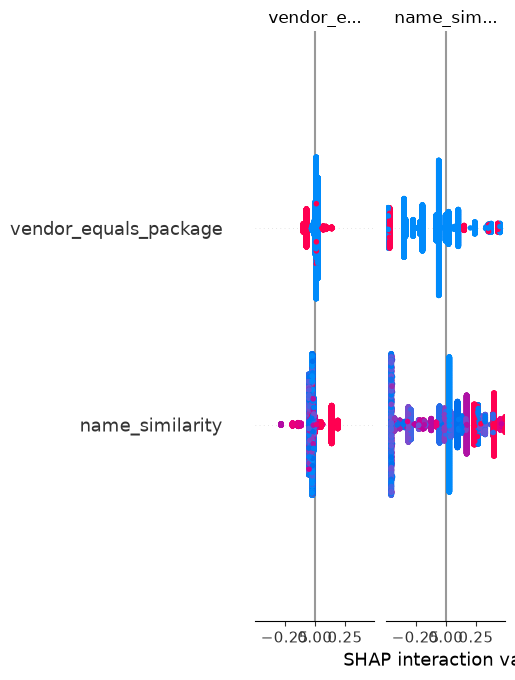

In [9]:
winner_name, winning_model, threshold = model.load_winning_model(model_dir=Path("..") / "models")
background = dataset[labeling.FEATURES].astype(float)
explainer = explain.make_explainer(winner_name, winning_model, background)
shap_values = explainer.shap_values(background)
shap.summary_plot(shap_values, background)

---
## 5. The agent's triage policy over every component

`agent.scan` runs `matching.find_candidates` (this week's version of Week
2's Section 2) for every component in `live_components` (Section 1d),
scores each vendor match with the winning model, checks CISA KEV, and
cross-checks OSV.dev - sorting every match into one of four buckets:

- **escalated** - KEV-listed (actively exploited in the wild)
- **confirmed** - above the model's threshold, or corroborated by OSV
- **review_queue** - below threshold and not OSV-corroborated; SHAP-explained
- **rejected** - name matched but version didn't apply, or no CPE vendor
  candidate at all (Week 2's "collision" case)

In [10]:
t0 = time.time()
result = agent.scan(live_components, winner_name, winning_model, threshold, explainer, conn=conn)
print(f"agent.scan took {time.time()-t0:.1f}s")
print("confirmed:", len(result.confirmed), " escalated:", len(result.escalated),
      " review_queue:", len(result.review_queue), " rejected:", len(result.rejected))
print("OSV agreement (sanity check on confirmed PyPI/npm findings):", report.osv_agreement_summary(result))

agent.scan took 4.0s
confirmed: 2  escalated: 0  review_queue: 0  rejected: 1
OSV agreement (sanity check on confirmed PyPI/npm findings): {'eligible': 2, 'agreed': 2, 'agreement_rate': 1.0}


---
## 6. Report output

`report.write_report` writes both a machine-readable JSON (`findings.json`)
and a presentation-ready HTML (`report.html`) with all four buckets,
escalated findings first.

In [11]:
out_dir = Path("..") / "reports" / "week3"
report.write_report(result, out_dir)
print(f"wrote {out_dir / 'findings.json'} and {out_dir / 'report.html'}")

wrote ..\reports\week3\findings.json and ..\reports\week3\report.html


---
## Summary

Week 3's milestone: every module from Weeks 1-2 (data pull, matching,
baseline model, risk framing, fairness framing) plus everything built
since (SBOM/image parsing, local caching, dual-model training with a
persisted winner, SHAP explanations, KEV/OSV corroboration, and a
four-bucket triage policy) runs as one pipeline against a real component
list, not as separate per-module demos.

Carries forward:
1. **The component schema and matching engine hold** - three input paths
   converge on it now, not one.
2. **Week 2's risk framing became a real policy**: low-confidence matches
   go to `review_queue` with a SHAP explanation instead of being silently
   dropped or silently trusted - the exact conclusion Week 2's risk
   analysis argued for.
3. **Live per-scan NVD/CPE calls are gone** for the CVE side; the CPE
   Dictionary side still needs external pacing (Section 2a) since it has
   no retry/backoff of its own.

Deferred: packaging `it_security_agent` for a real install, a bigger
training set, and exercising `image_scan.py` against a live Syft/Docker
setup once one is available.

---
## Test coverage

Verified run, `uv run pytest --cov=it_security_agent --cov-report=term-missing`:

```
Name                                  Stmts   Miss  Cover   Missing
-------------------------------------------------------------------
it_security_agent\__init__.py             0      0   100%
it_security_agent\agent.py               55      2    96%   54-58
it_security_agent\cpe_dictionary.py      20      0   100%
it_security_agent\explain.py             15      2    87%   15, 19
it_security_agent\image_scan.py          14      0   100%
it_security_agent\kev.py                 22      0   100%
it_security_agent\labeling.py            16      0   100%
it_security_agent\matching.py            76     10    87%   9-10, 20, 22, 47, 53-55, 63, 75
it_security_agent\model.py               51      2    96%   55, 67
it_security_agent\normalize.py           39      1    97%   39
it_security_agent\nvd_cache.py           32      5    84%   43-50
it_security_agent\nvd_client.py          38      7    82%   19-23, 29-30
it_security_agent\osv.py                 23      0   100%
it_security_agent\registry.py            38      1    97%   20
it_security_agent\repo_scan.py           24      1    96%   29
it_security_agent\report.py              34      0   100%
it_security_agent\sbom.py                23      0   100%
it_security_agent\schema.py              15      0   100%
-------------------------------------------------------------------
TOTAL                                   535     31    94%
69 passed, 3 warnings in 17.32s
```

Every module clears the 80% bar; total is 94%. The 3 warnings are
`PendingDeprecationWarning`s from `shap`'s own colormap code on import
(not from our test code), not something worth chasing.